# Image Super Resolution using ESRGAN

## 🧠 What is ESRGAN?

ESRGAN is a type of GAN (Generative Adversarial Network) that turns low-quality, blurry images into sharp, high-resolution ones.

Think of it like photo enhancement magic — it takes a pixelated image and makes it look much clearer and more detailed.



---



### 🧩 Real-Life Analogy

Imagine:
	•	You have a tiny, blurry passport photo.
	•	You give it to a smart artist (the ESRGAN generator) and ask:

“Please draw what this person really looks like.”

The artist:
	•	Fills in missing details like eyelashes, hair texture, or shirt pattern — based on what real people usually look like.
	•	A critic (discriminator) judges whether the result looks like a real high-quality photo.

They train together until the artist gets so good that the critic can’t tell the difference.

---

## 🔍 What Makes ESRGAN Special?

Compared to earlier models like SRGAN, ESRGAN:
-	Adds more realistic textures.
-	Keeps sharp edges (no more overly smooth results).
-	Uses something called Residual-in-Residual Dense Blocks (RRDB) – sounds technical, but it just means better “memory” and pattern understanding while enhancing details.
-	Focuses on perceptual quality (how natural it looks, not just pixel accuracy).

---

## 🖼️ Example Result:

You give ESRGAN a blurry 64×64 image of a face → it outputs a clear, detailed 256×256 image that looks like a real photo.

### Preparing the Enivornment Setup

In [1]:
import os
import time
from PIL import Image
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
os.environ['TFHUB_DOWNLOAD_PROGRESS'] = "True"

In [2]:
!wget = "https://www.usaoncanvas.com/images/low_res_addnoise.jpg"

--2026-06-14 06:13:22--  http://=/
Resolving = (=)... failed: Name or service not known.
wget: unable to resolve host address ‘=’
--2026-06-14 06:13:22--  https://www.usaoncanvas.com/images/low_res_addnoise.jpg
Resolving www.usaoncanvas.com (www.usaoncanvas.com)... 208.109.35.202
Connecting to www.usaoncanvas.com (www.usaoncanvas.com)|208.109.35.202|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65108 (64K) [image/jpeg]
Saving to: ‘low_res_addnoise.jpg’

low_res_addnoise.jp 100%[===================>]  63.58K  --.-KB/s    in 0.1s    

2026-06-14 06:13:22 (592 KB/s) - ‘low_res_addnoise.jpg’ saved [65108/65108]

FINISHED --2026-06-14 06:13:22--
Total wall clock time: 0.4s
Downloaded: 1 files, 64K in 0.1s (592 KB/s)


In [3]:
### Declaring Constants
IMAGE_PATH = "/content/low_res_addnoise.jpg"
SAVED_MODEL_PATH = "https://tfhub.dev/captain-pool/esrgan-tf2/1"

Defining Helper Function

In [4]:
def preprocess_image(image_path):
  hr_image = tf.image.decode_image(tf.io.read_file(image_path))
  if hr_image.shape[-1] == 4:
    hr_image = hr_image[...,:-1]
  hr_size = (tf.convert_to_tensor(hr_image.shape[:-1]) // 4) *4
  hr_image = tf.image.crop_to_bounding_box(hr_image, 0, 0, hr_size[0], hr_size[1])
  hr_image = tf.cast(hr_image, tf.float32)
  return tf.expand_dims(hr_image, 0)

def save_image(image, filename):
  if not isinstance(image, Image.Image):
    image = tf.clip_by_value(image, 0 , 225)
    image = Image.fromarray(tf.cast(image, tf.uint8).numpy())
  image.save("%s.jpeg" % filename)
  print("Saved as %s.jpeg" % filename)


In [5]:
import numpy as np

In [6]:
%matplotlib inline
def plot_image(image, title=""):
  image = np.asarray(image)
  image = tf.clip_by_value(image, 0, 255)
  image = Image.fromarray(tf.cast(image, tf.uint8).numpy())
  plt.imshow(image)
  plt.axis("off")
  plt.title(title)



In [7]:
hr_image =   preprocess_image(IMAGE_PATH)

Performing resolution of Image loaded from path

Saved as Original Image.jpeg


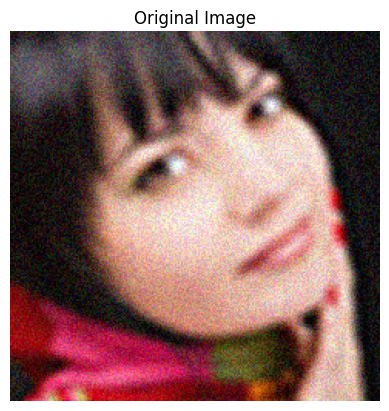

In [8]:
## Ploting Original Resolution Image
plot_image(tf.squeeze(hr_image), title="Original Image")
save_image(tf.squeeze(hr_image), filename="Original Image")


In [9]:
model = hub.load(SAVED_MODEL_PATH)

Downloaded https://tfhub.dev/captain-pool/esrgan-tf2/1, Total size: 20.60MB



In [10]:
start = time.time()
fake_image = model(hr_image)
fake_image = tf.squeeze(fake_image)
print("Time Taken: %f" % (time.time() - start))

Time Taken: 13.918079


Saved as Super Resolution.jpeg


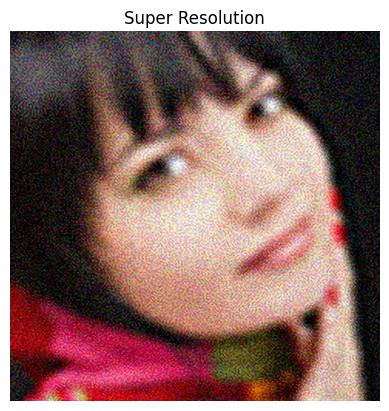

In [11]:
###  Ploting Resolution Image
plot_image(tf.squeeze(fake_image), title="Super Resolution")
save_image(tf.squeeze(fake_image), filename="Super Resolution")

In [12]:
!wget "https://lh4.googleusercontent.com/-Anmw5df4gj0/AAAAAAAAAAI/AAAAAAAAAAc/6HxU8XFLnQE/photo.jpg64" -O test.jpg
IMAGE_PATH = "test.jpg"

--2026-06-14 06:16:07--  https://lh4.googleusercontent.com/-Anmw5df4gj0/AAAAAAAAAAI/AAAAAAAAAAc/6HxU8XFLnQE/photo.jpg64
Resolving lh4.googleusercontent.com (lh4.googleusercontent.com)... 172.253.62.132, 2607:f8b0:4004:c07::84
Connecting to lh4.googleusercontent.com (lh4.googleusercontent.com)|172.253.62.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85087 (83K) [image/jpeg]
Saving to: ‘test.jpg’

test.jpg            100%[===================>]  83.09K  --.-KB/s    in 0.02s   

2026-06-14 06:16:07 (5.18 MB/s) - ‘test.jpg’ saved [85087/85087]



In [13]:
# Defining helper functions
def downscale_image(image):
  """
      Scales down images using bicubic downsampling.
      Args:
          image: 3D or 4D tensor of preprocessed image
  """
  image_size = []
  if len(image.shape) == 3:
    image_size = [image.shape[1], image.shape[0]]
  else:
    raise ValueError("Dimension mismatch. Can work only on single image.")

  image = tf.squeeze(
      tf.cast(
          tf.clip_by_value(image, 0, 255), tf.uint8))

  lr_image = np.asarray(
    Image.fromarray(image.numpy())
    .resize([image_size[0] // 4, image_size[1] // 4],
              Image.BICUBIC))

  lr_image = tf.expand_dims(lr_image, 0)
  lr_image = tf.cast(lr_image, tf.float32)
  return lr_image

In [14]:
hr_image = preprocess_image(IMAGE_PATH)

In [43]:
hr_image = preprocess_image(IMAGE_PATH)

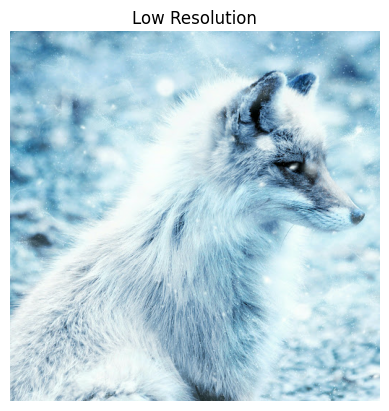

In [15]:
# Plotting Low Resolution Image
plot_image(tf.squeeze(hr_image), title="Low Resolution")

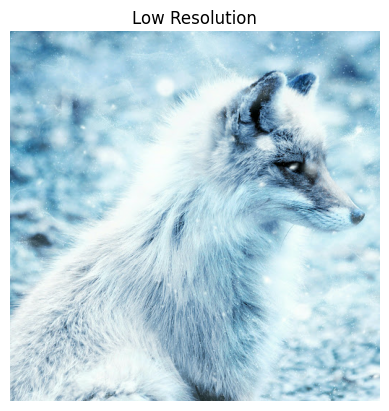

In [16]:
# Plotting Low Resolution Image
plot_image(tf.squeeze(hr_image), title="Low Resolution")